# Forest Cover Classification in Assam from Satellite Data

**Goal:** use satellite imagery and machine learning to classify each piece of land in Assam, India as **forest** or **non-forest**, and track how forest cover changed from 2015–2023.

The interesting part of this project is the data engineering: it fuses four completely different satellite/earth-observation sources — all processed on Google's servers — then samples them into a tidy table and trains two models on it.

### Data sources
| Source | What it gives us |
|---|---|
| **Landsat 8** (surface reflectance) | NDVI & EVI — vegetation "greenness" indices |
| **ERA5-Land** | climate: mean temperature, total precipitation |
| **SRTM DEM** | topography: elevation, slope |
| **Hansen Global Forest Change** | the labels (forest / non-forest, plus year-of-loss) |

### A note on running this notebook
The data-collection step uses **Google Earth Engine (GEE)**, which needs a Google service-account login and server access. That code is included and explained below, but to keep the notebook runnable end-to-end *without* credentials, Section 2 generates a **synthetic sample with the same columns** the GEE step would produce. Everything after that — cleaning, feature engineering, modelling, evaluation, charts — runs on whatever DataFrame exists, so you can swap the synthetic block for your real GEE calls and the rest is unchanged.

## 0. Setup & configuration

All project parameters live in one config dictionary, mirroring `config.py`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, f1_score, roc_curve)
import lightgbm as lgb

CONFIG = {
    "region": "Assam", "gaul_field": "ADM1_NAME",
    "start_year": 2015, "end_year": 2023,
    "cloud_threshold": 30, "forest_threshold": 30,
    "scale": 500, "seed": 42,
}
FEATURE_COLS = ["NDVI", "EVI", "mean_temp", "total_precip", "elevation", "slope"]
TARGET_COL = "label"
np.random.seed(CONFIG["seed"])

## 1. Data collection from Google Earth Engine (methodology)

This is the code that pulls and pre-processes the satellite data **on GEE's servers** — we never download whole images, only a small table of sampled points. The functions below are defined here so you can read the methodology; the `import ee` is guarded so the cell runs even without GEE installed. To use them for real you would authenticate with a service account and call `fetch_samples_for_year(boundary, year)` for each year.

Key ideas worth understanding:
- **NDVI** = (NIR − Red)/(NIR + Red): healthy vegetation reflects near-infrared strongly, so forest scores high (~0.7–0.9) and bare land low. **EVI** is a refined version that doesn't saturate over dense canopy.
- **Cloud masking** uses the Landsat `QA_PIXEL` quality band (bits for cloud and shadow) to drop bad pixels.
- **Median compositing**: for each year we take the per-pixel median across all clear images — robust to the odd hazy day.
- **Hansen labels**: a pixel is "forest" in year *Y* if it had ≥30% tree cover in 2000 **and** hadn't been cleared by year *Y*.
- **Stratified sampling**: instead of millions of pixels we sample a balanced set of forest / non-forest points per year.

In [2]:
try:
    import ee
    EE_AVAILABLE = True
except ImportError:
    EE_AVAILABLE = False   # notebook still runs; GEE functions just aren't called

def initialize_gee(service_account_key: dict):
    credentials = ee.ServiceAccountCredentials(
        email=service_account_key["client_email"],
        key_data=service_account_key["private_key"])
    ee.Initialize(credentials)

def get_assam_boundary():
    return (ee.FeatureCollection("FAO/GAUL/2015/level1")
            .filter(ee.Filter.eq(CONFIG["gaul_field"], CONFIG["region"])))

def mask_landsat_clouds(image):
    qa = image.select("QA_PIXEL")
    cloud = qa.bitwiseAnd(1 << 3).eq(0)
    shadow = qa.bitwiseAnd(1 << 4).eq(0)
    return image.updateMask(cloud.And(shadow))

def compute_indices(image):
    ndvi = image.normalizedDifference(["SR_B5", "SR_B4"]).rename("NDVI")
    evi = image.expression(
        "2.5 * ((NIR - RED) / (NIR + 6 * RED - 7.5 * BLUE + 1))",
        {"NIR": image.select("SR_B5"), "RED": image.select("SR_B4"),
         "BLUE": image.select("SR_B2")}).rename("EVI")
    return image.addBands([ndvi, evi])

def get_annual_composite(year, region):
    coll = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
            .filterBounds(region)
            .filterDate(f"{year}-01-01", f"{year}-12-31")
            .filter(ee.Filter.lt("CLOUD_COVER", CONFIG["cloud_threshold"]))
            .map(mask_landsat_clouds).map(compute_indices))
    return coll.median().select(["NDVI", "EVI"]).clip(region)

def get_hansen_labels(region):
    hansen = ee.Image("UMD/hansen/global_forest_change_2023_v1_11")
    tree_cover = hansen.select("treecover2000")
    loss_year = hansen.select("lossyear")
    end_off = CONFIG["end_year"] - 2000
    forest = tree_cover.gte(CONFIG["forest_threshold"]).And(
        loss_year.eq(0).Or(loss_year.gt(end_off)))
    return forest.rename("label").clip(region), loss_year.rename("loss_year").clip(region)

# (climate, topography, and stratified-sampling helpers omitted here for brevity —
#  they stack ERA5 + SRTM bands and call stacked.stratifiedSample(numPoints=1500, ...))
print("GEE functions defined. earthengine-api available:", EE_AVAILABLE)

GEE functions defined. earthengine-api available: False


## 2. Build the dataset

With a GEE login you would loop over the years and concatenate `fetch_samples_for_year(...)` results. Here we generate a **synthetic sample** with the exact columns that step produces — `longitude, latitude, year, NDVI, EVI, mean_temp, total_precip, elevation, slope, label, loss_year` — so the rest of the pipeline is fully runnable. Forest pixels are given higher NDVI/EVI, and a fraction of forest locations are cleared partway through the period to create realistic deforestation.

In [3]:
# ---- SYNTHETIC SAMPLE standing in for the GEE output (replace with real data) ----
rng = np.random.default_rng(CONFIG["seed"])
n_loc = 600
years = list(range(CONFIG["start_year"], CONFIG["end_year"] + 1))

lons = rng.uniform(89.5, 96.0, n_loc)              # Assam longitudes
lats = rng.uniform(24.0, 28.0, n_loc)              # Assam latitudes
elev = rng.gamma(2.0, 80, n_loc).clip(0, 2500)     # metres
slope = (elev / 2500 * 30 + rng.normal(0, 3, n_loc)).clip(0, 45)
is_forest = rng.random(n_loc) < 0.58               # baseline forest status

loss_year = np.zeros(n_loc, dtype=int)             # deforestation events
for i in range(n_loc):
    if is_forest[i] and rng.random() < 0.10:
        loss_year[i] = rng.integers(2017, 2023)

rows = []
for i in range(n_loc):
    for y in years:
        forest = bool(is_forest[i] and (loss_year[i] == 0 or y < loss_year[i]))
        if forest:
            ndvi, evi = rng.normal(0.60, 0.12), rng.normal(0.44, 0.10)
        else:
            ndvi, evi = rng.normal(0.44, 0.13), rng.normal(0.30, 0.10)
        rows.append(dict(
            longitude=lons[i], latitude=lats[i], year=y,
            NDVI=float(np.clip(ndvi + rng.normal(0, 0.02), -1, 1)),
            EVI=float(np.clip(evi, -1, 1)),
            mean_temp=297 - elev[i] * 0.006 + rng.normal(0, 0.5),   # ~Kelvin
            total_precip=max(rng.normal(2.2, 0.4), 0),
            elevation=float(elev[i]), slope=float(slope[i]),
            label=int(forest), loss_year=int(loss_year[i])))
df = pd.DataFrame(rows)

print("Dataset shape:", df.shape)
print("Forest share by year:")
print((df.groupby("year")["label"].mean() * 100).round(1))
df.head()

Dataset shape: (5400, 11)
Forest share by year:
year
2015    58.0
2016    58.0
2017    56.3
2018    55.3
2019    54.5
2020    53.5
2021    52.5
2022    51.8
2023    51.8
Name: label, dtype: float64


,longitude,latitude,year,NDVI,EVI,mean_temp,total_precip,elevation,slope,label,loss_year
0,94.530714,25.910023,2015,0.745330,0.486973,297.408587,2.246072,55.2732,0.0,1,0
1,94.530714,25.910023,2016,0.577540,0.356218,297.286886,2.179765,55.2732,0.0,1,0
2,94.530714,25.910023,2017,0.755841,0.242998,296.648313,1.909202,55.2732,0.0,1,0
3,94.530714,25.910023,2018,0.877909,0.433381,296.681342,1.398875,55.2732,0.0,1,0
4,94.530714,25.910023,2019,0.496237,0.538324,296.253923,2.723810,55.2732,0.0,1,0


## 3. Clean the data

Drop rows missing any feature or label, and remove physically impossible values (NDVI/EVI outside −1..1, negative elevation). This mirrors `preprocessing.clean_data`.

In [4]:
def clean_data(df):
    initial = len(df)
    df = df.dropna(subset=FEATURE_COLS + [TARGET_COL])
    df = df[df["NDVI"].between(-1, 1)]
    df = df[df["EVI"].between(-1, 1)]
    df = df[df["elevation"] >= 0]
    return df.reset_index(drop=True), initial - len(df)

df, dropped = clean_data(df)
print(f"Rows after cleaning: {len(df):,}  (dropped {dropped})")

Rows after cleaning: 5,400  (dropped 0)


## 4. Temporal feature engineering

The raw points are independent observations. To give the model a sense of *change over time*, we group by location and add three NDVI history features: last year's value (`NDVI_lag1`), a 3-year rolling mean (`NDVI_roll3`), and the year-on-year change (`NDVI_delta`). This is what turns a pile of points into something with a time dimension (mirrors `add_temporal_features`).

The first year of each location has no "previous year", so those rows get NaN in the lag/delta features — we drop them before modelling.

In [5]:
def add_temporal_features(df):
    df = df.sort_values(["longitude", "latitude", "year"]).reset_index(drop=True)
    grp = ["longitude", "latitude"]
    df["NDVI_lag1"] = df.groupby(grp)["NDVI"].shift(1)
    df["NDVI_roll3"] = (df.groupby(grp)["NDVI"]
                          .transform(lambda x: x.rolling(3, min_periods=1).mean()))
    df["NDVI_delta"] = df["NDVI"] - df["NDVI_lag1"]
    extended = FEATURE_COLS + ["NDVI_lag1", "NDVI_roll3", "NDVI_delta"]
    return df, extended

df, EXTENDED = add_temporal_features(df)
df = df.dropna(subset=EXTENDED).reset_index(drop=True)   # drop each location's first year
print("Modelling features:", EXTENDED)
print("Rows available for modelling:", len(df))

Modelling features: ['NDVI', 'EVI', 'mean_temp', 'total_precip', 'elevation', 'slope', 'NDVI_lag1', 'NDVI_roll3', 'NDVI_delta']
Rows available for modelling: 4800


## 5. Temporal train/test split

We train on the **earlier** years and test on the **latest** ones (2022–2023) — deliberately *not* a random split. A random split would let the model peek at the future; a time-based split mimics how you'd actually deploy this and is the honest way to validate a temporal model.

In [6]:
def temporal_split(df, test_years, feature_cols):
    train_df = df[~df["year"].isin(test_years)]
    test_df  = df[df["year"].isin(test_years)]
    available = [c for c in feature_cols if c in df.columns]
    return (train_df[available].values, test_df[available].values,
            train_df[TARGET_COL].astype(int).values,
            test_df[TARGET_COL].astype(int).values, available)

TEST_YEARS = [2022, 2023]
X_train, X_test, y_train, y_test, available = temporal_split(df, TEST_YEARS, EXTENDED)
print(f"Train rows: {len(X_train):,}   Test rows: {len(X_test):,}")
print("Train forest %:", round(y_train.mean()*100, 1),
      " | Test forest %:", round(y_test.mean()*100, 1))

Train rows: 3,600   Test rows: 1,200
Train forest %: 55.0  | Test forest %: 51.8


## 6. Train two models

We compare a **Random Forest** and **LightGBM** (gradient boosting), each in a scikit-learn `Pipeline`. `class_weight="balanced"` guards against class imbalance.

*Honest note:* the `StandardScaler` is kept to match the original code, but tree-based models are scale-invariant — it doesn't help or hurt them. Worth knowing for an interview.

In [7]:
def build_random_forest():
    return Pipeline([("scaler", StandardScaler()),
        ("clf", RandomForestClassifier(n_estimators=200, max_depth=15,
            min_samples_leaf=10, class_weight="balanced", n_jobs=-1,
            random_state=CONFIG["seed"]))])

def build_lightgbm():
    return Pipeline([("scaler", StandardScaler()),
        ("clf", lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05,
            num_leaves=63, max_depth=10, min_child_samples=20, subsample=0.8,
            colsample_bytree=0.8, class_weight="balanced", n_jobs=-1,
            random_state=CONFIG["seed"], verbose=-1))])

models = {"Random Forest": build_random_forest(), "LightGBM": build_lightgbm()}
for name, m in models.items():
    m.fit(X_train, y_train)
    print(f"Trained {name}")

Trained Random Forest
Trained LightGBM


## 7. Evaluate

**ROC-AUC** measures ranking quality across all thresholds (good for imbalanced data); **F1** balances precision and recall at the default threshold. We report both.

In [8]:
def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    return {"roc_auc": round(roc_auc_score(y_test, y_proba), 4),
            "f1": round(f1_score(y_test, y_pred), 4),
            "confusion_matrix": confusion_matrix(y_test, y_pred),
            "report": classification_report(y_test, y_pred,
                target_names=["Non-Forest", "Forest"], output_dict=True),
            "y_pred": y_pred, "y_proba": y_proba}

results = {name: evaluate_model(m, X_test, y_test) for name, m in models.items()}
pd.DataFrame({name: {"ROC-AUC": r["roc_auc"], "F1": r["f1"]}
              for name, r in results.items()}).T

,ROC-AUC,F1
Random Forest,0.9709,0.9230
LightGBM,0.9730,0.9231


In [9]:
best = max(results, key=lambda n: results[n]["roc_auc"])
print(f"Classification report — {best}\n")
print(classification_report(y_test, results[best]["y_pred"],
                            target_names=["Non-Forest", "Forest"]))

Classification report — LightGBM

              precision    recall  f1-score   support

  Non-Forest       0.94      0.89      0.91       578
      Forest       0.90      0.95      0.92       622

    accuracy                           0.92      1200
   macro avg       0.92      0.92      0.92      1200
weighted avg       0.92      0.92      0.92      1200



## 8. Visualisations

### NDVI distribution: forest vs non-forest
This is the signal the whole model rests on — the two classes should separate cleanly in NDVI.

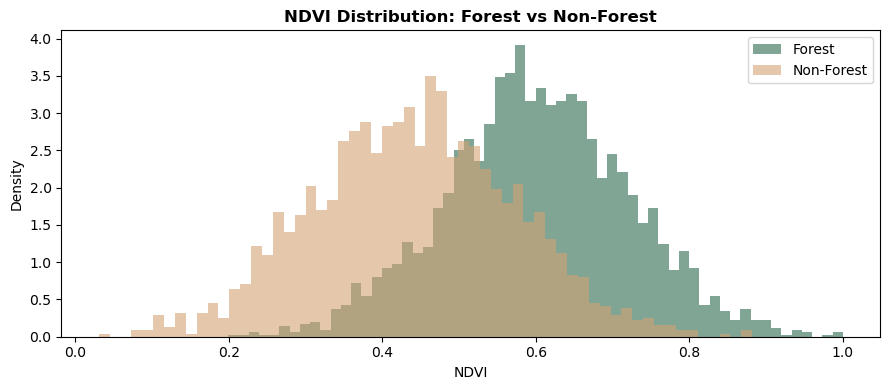

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
for label, color, name in [(1, "#2d6a4f", "Forest"), (0, "#d4a373", "Non-Forest")]:
    ax.hist(df[df["label"] == label]["NDVI"].dropna(), bins=60, alpha=0.6,
            color=color, label=name, density=True)
ax.set_title("NDVI Distribution: Forest vs Non-Forest", fontweight="bold")
ax.set_xlabel("NDVI"); ax.set_ylabel("Density"); ax.legend()
plt.tight_layout(); plt.show()

### Confusion matrix and ROC curves

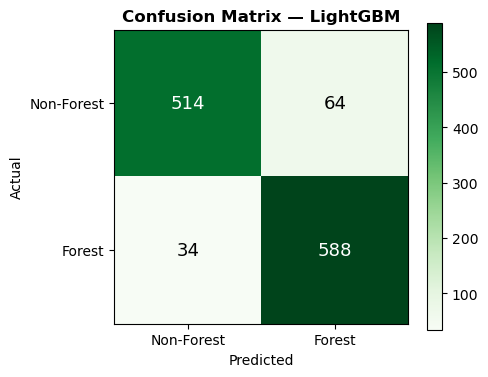

In [11]:
cm = results[best]["confusion_matrix"]
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Greens")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(["Non-Forest", "Forest"]); ax.set_yticklabels(["Non-Forest", "Forest"])
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title(f"Confusion Matrix — {best}", fontweight="bold")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=13)
plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

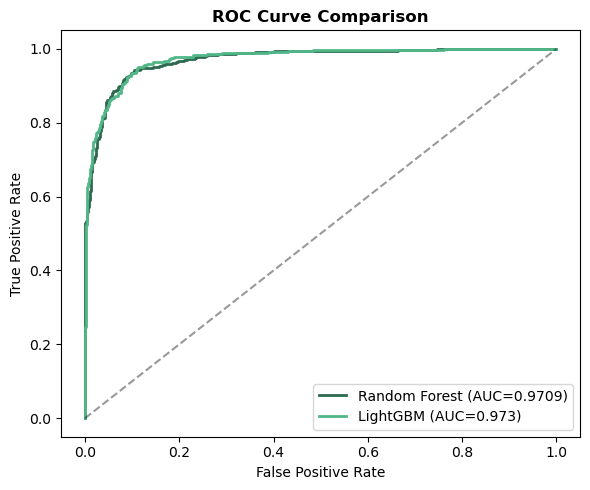

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
colors = {"Random Forest": "#2d6a4f", "LightGBM": "#52b788"}
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']})", color=colors[name], lw=2)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve Comparison", fontweight="bold"); ax.legend()
plt.tight_layout(); plt.show()

### Feature importance

We expect NDVI (and its temporal derivatives) and EVI to dominate — vegetation greenness is the core signal.

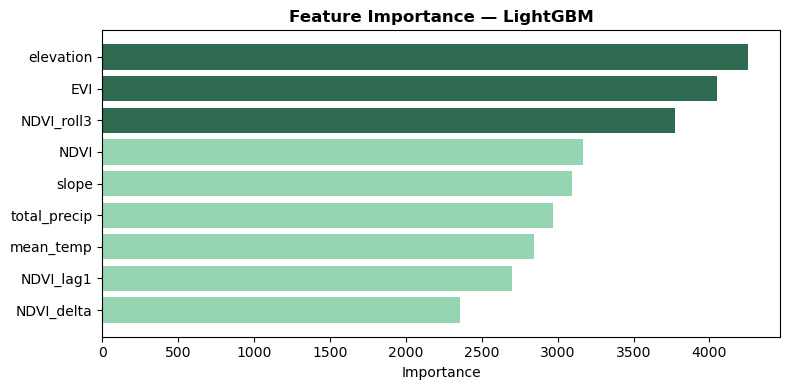

,feature,importance
0,elevation,4252
1,EVI,4047
2,NDVI_roll3,3774
3,NDVI,3168
4,slope,3091
5,total_precip,2967
6,mean_temp,2843
7,NDVI_lag1,2698
8,NDVI_delta,2358


In [13]:
clf = models[best].named_steps["clf"]
imp = (pd.DataFrame({"feature": available, "importance": clf.feature_importances_})
       .sort_values("importance", ascending=False).reset_index(drop=True))
fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#2d6a4f" if i < 3 else "#95d5b2" for i in range(len(imp))]
ax.barh(imp["feature"][::-1], imp["importance"][::-1], color=colors[::-1])
ax.set_title(f"Feature Importance — {best}", fontweight="bold"); ax.set_xlabel("Importance")
plt.tight_layout(); plt.show()
imp

### Forest cover trend over time

Predict forest/non-forest for every year and average to get an annual forest-cover percentage.

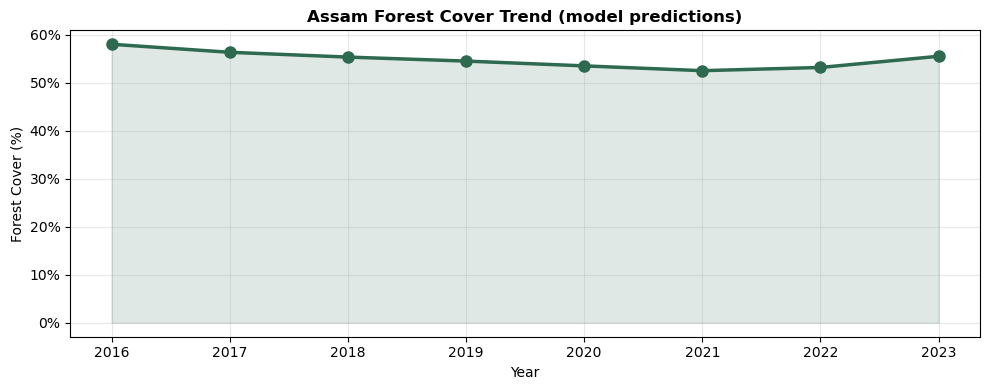

,year,forest_cover_pct,n_samples
0,2016,58.00,600
1,2017,56.33,600
2,2018,55.33,600
3,2019,54.50,600
4,2020,53.50,600
5,2021,52.50,600
6,2022,53.17,600
7,2023,55.50,600


In [14]:
def annual_forest_cover(model, df, feature_cols):
    records = []
    for year in sorted(df["year"].unique()):
        dfy = df[df["year"] == year]
        X = dfy[[c for c in feature_cols if c in dfy.columns]].dropna().values
        if len(X) == 0:
            continue
        preds = model.predict(X)
        records.append({"year": int(year),
                        "forest_cover_pct": round(float(preds.mean()*100), 2),
                        "n_samples": len(preds)})
    return pd.DataFrame(records)

cover = annual_forest_cover(models[best], df, available)
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cover["year"], cover["forest_cover_pct"], marker="o", lw=2.5,
        color="#2d6a4f", markersize=8)
ax.fill_between(cover["year"], cover["forest_cover_pct"], alpha=0.15, color="#2d6a4f")
ax.set_title("Assam Forest Cover Trend (model predictions)", fontweight="bold")
ax.set_xlabel("Year"); ax.set_ylabel("Forest Cover (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter()); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
cover

## 9. Limitations & next steps

Being able to discuss these honestly is the most valuable part of the project in an interview:

- **The cover % is biased by the sampling design.** The real GEE step uses *stratified* sampling (a balanced ~50/50 forest/non-forest set each year), so averaging predictions over it does **not** estimate Assam's true forest fraction. A random (unstratified) sample, or area-weighting, would be needed for a true cover figure.
- **Spatial leakage.** Because roughly the same locations are sampled every year, a pixel's early-year rows sit in training and its late-year rows in testing. With near-static topography/climate, the model can partly memorise "this location = forest", inflating test scores. A **spatial** hold-out (entire regions) or spatial cross-validation is more rigorous.
- **Partial circularity.** Features predict a Hansen-derived label, and the trend re-derives Hansen — so this reproduces the reference dataset rather than independently measuring deforestation.
- **The `loss_year` band is unused.** Predicting actual *loss events* (change detection) would be a more compelling project than static forest/non-forest classification.
- **Scaler is redundant** for tree models (kept only to match the original).

**Strong next step:** reframe around change detection using `loss_year` as the target, with a proper spatial split. That single change lifts this from a solid classification demo to a genuinely useful deforestation-detection project.

*Built with scikit-learn, LightGBM, and (for real data) Google Earth Engine.*